Import Libraries

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

Load Dataset

In [31]:
df = pd.read_csv("Employee_Attrition.csv")

In [32]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [33]:
df.shape

(1470, 35)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [35]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [36]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Attrition Distribution

In [39]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

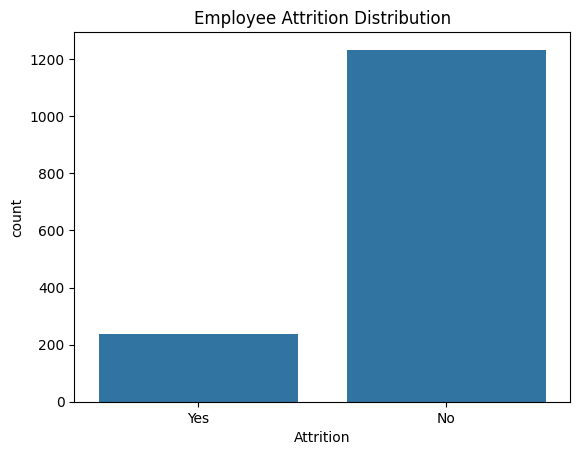

In [40]:
sns.countplot(x="Attrition",data=df)

plt.title("Employee Attrition Distribution")

plt.show()

Drop Unnecessary Columns

In [41]:
df = df.drop(
    [
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ],
    axis=1
)

In [42]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [43]:
df["Attrition"] = df["Attrition"].map(
    {
        "Yes":1,
        "No":0
    }
)

In [71]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [44]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [45]:
le = LabelEncoder()

for column in df.columns:

    if df[column].dtype=="object":

        df[column]=le.fit_transform(df[column])

In [46]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   int64
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   int64
 14  JobSatisfaction           1470 non-null 

Separate Features & Target

In [48]:
X = df.drop("Attrition",axis=1)

y = df["Attrition"]

Check Shape

In [49]:
print(X.shape)

print(y.shape)

(1470, 30)
(1470,)


Train Test Split

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1176, 30)
(294, 30)
(1176,)
(294,)


Logistic Regression

In [54]:
lr = LogisticRegression(
    solver="liblinear",
    max_iter=5000,
    random_state=42
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

prob_lr = lr.predict_proba(X_test)[:,1]

Decision Tree

In [55]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

prob_dt = dt.predict_proba(X_test)[:,1]

Random Forest

In [56]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

KNN

In [57]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

prob_knn = knn.predict_proba(X_test)[:,1]

Logistic Regression Metrics

In [58]:
print("Accuracy :", accuracy_score(y_test,pred_lr))

print("Precision :", precision_score(y_test,pred_lr))

print("Recall :", recall_score(y_test,pred_lr))

print("F1 Score :", f1_score(y_test,pred_lr))

print("ROC AUC :", roc_auc_score(y_test,prob_lr))

Accuracy : 0.8775510204081632
Precision : 0.7142857142857143
Recall : 0.1282051282051282
F1 Score : 0.21739130434782608
ROC AUC : 0.7434891905480141


Decision Tree Metrics

In [59]:
print("Accuracy :", accuracy_score(y_test,pred_dt))

print("Precision :", precision_score(y_test,pred_dt))

print("Recall :", recall_score(y_test,pred_dt))

print("F1 Score :", f1_score(y_test,pred_dt))

print("ROC AUC :", roc_auc_score(y_test,prob_dt))

Accuracy : 0.7993197278911565
Precision : 0.23684210526315788
Recall : 0.23076923076923078
F1 Score : 0.23376623376623376
ROC AUC : 0.5585218702865762


Random Forest Metrics

In [60]:
print("Accuracy :", accuracy_score(y_test,pred_rf))

print("Precision :", precision_score(y_test,pred_rf))

print("Recall :", recall_score(y_test,pred_rf))

print("F1 Score :", f1_score(y_test,pred_rf))

print("ROC AUC :", roc_auc_score(y_test,prob_rf))

Accuracy : 0.8809523809523809
Precision : 0.8333333333333334
Recall : 0.1282051282051282
F1 Score : 0.2222222222222222
ROC AUC : 0.734640522875817


KNN Metrics

In [61]:
print("Accuracy :", accuracy_score(y_test,pred_knn))

print("Precision :", precision_score(y_test,pred_knn))

print("Recall :", recall_score(y_test,pred_knn))

print("F1 Score :", f1_score(y_test,pred_knn))

print("ROC AUC :", roc_auc_score(y_test,prob_knn))

Accuracy : 0.8469387755102041
Precision : 0.3125
Recall : 0.1282051282051282
F1 Score : 0.18181818181818182
ROC AUC : 0.5064353946706888


Performance Comparison Table

In [62]:
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Decision Tree',
'Random Forest',
'KNN'
],

'Accuracy':[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_knn)
],

'Precision':[
precision_score(y_test,pred_lr),
precision_score(y_test,pred_dt),
precision_score(y_test,pred_rf),
precision_score(y_test,pred_knn)
],

'Recall':[
recall_score(y_test,pred_lr),
recall_score(y_test,pred_dt),
recall_score(y_test,pred_rf),
recall_score(y_test,pred_knn)
],

'F1 Score':[
f1_score(y_test,pred_lr),
f1_score(y_test,pred_dt),
f1_score(y_test,pred_rf),
f1_score(y_test,pred_knn)
],

'ROC AUC':[
roc_auc_score(y_test,prob_lr),
roc_auc_score(y_test,prob_dt),
roc_auc_score(y_test,prob_rf),
roc_auc_score(y_test,prob_knn)
]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.877551,0.714286,0.128205,0.217391,0.743489
1,Decision Tree,0.799320,0.236842,0.230769,0.233766,0.558522
2,Random Forest,0.880952,0.833333,0.128205,0.222222,0.734641
3,KNN,0.846939,0.312500,0.128205,0.181818,0.506435


Accuracy Graph

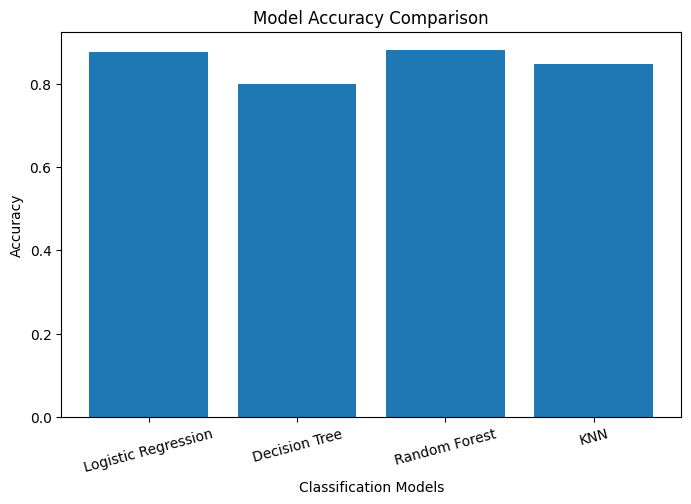

In [63]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"],results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Classification Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

Confusion Matrix

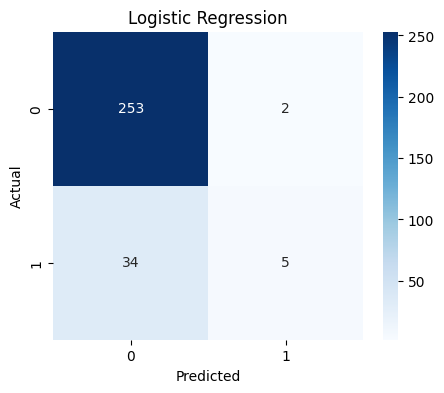

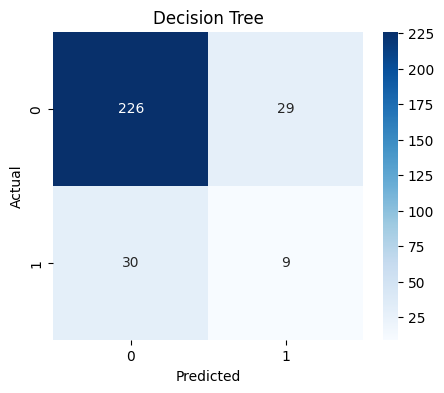

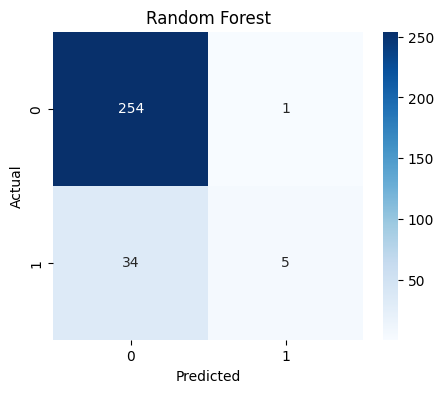

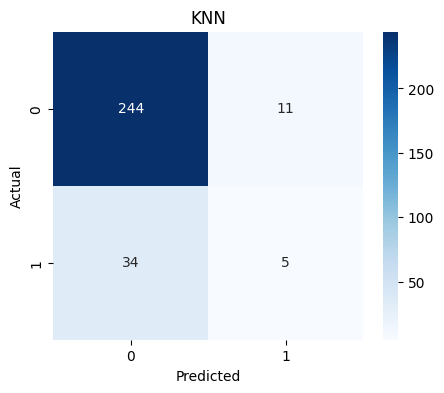

In [64]:
models = {

"Logistic Regression":pred_lr,

"Decision Tree":pred_dt,

"Random Forest":pred_rf,

"KNN":pred_knn

}

for name,pred in models.items():

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(y_test,pred)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

Classification Report

In [65]:
print("Logistic Regression")
print(classification_report(y_test,pred_lr))

print("Decision Tree")
print(classification_report(y_test,pred_dt))

print("Random Forest")
print(classification_report(y_test,pred_rf))

print("KNN")
print(classification_report(y_test,pred_knn))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       255
           1       0.24      0.23      0.23        39

    accuracy                           0.80       294
   macro avg       0.56      0.56      0.56       294
weighted avg       0.80      0.80      0.80       294

Random Forest
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88   

ROC Curve Comparison

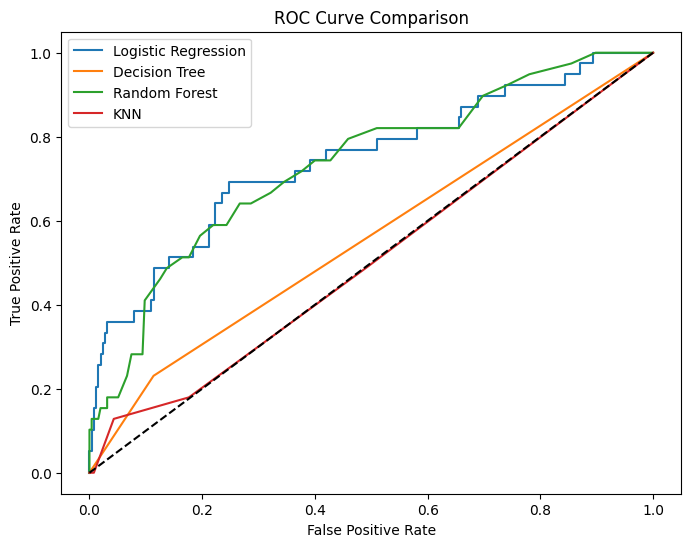

In [66]:
plt.figure(figsize=(8,6))

models = {

"Logistic Regression":prob_lr,

"Decision Tree":prob_dt,

"Random Forest":prob_rf,

"KNN":prob_knn

}

for name,prob in models.items():

    fpr,tpr,_ = roc_curve(y_test,prob)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

Best Model

In [67]:
results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.880952,0.833333,0.128205,0.222222,0.734641
0,Logistic Regression,0.877551,0.714286,0.128205,0.217391,0.743489
3,KNN,0.846939,0.312500,0.128205,0.181818,0.506435
1,Decision Tree,0.799320,0.236842,0.230769,0.233766,0.558522


In [68]:
best_model = results.loc[results["Accuracy"].idxmax()]

print(best_model)

Model        Random Forest
Accuracy          0.880952
Precision         0.833333
Recall            0.128205
F1 Score          0.222222
ROC AUC           0.734641
Name: 2, dtype: object


In [69]:
results.to_csv("Model_Comparison_Report.csv", index=False)

print("Model Comparison Report Saved Successfully.")

Model Comparison Report Saved Successfully.
